# Mạng Nơ-ron Sâu để Phân loại Hình ảnh: Ứng dụng

Khi hoàn thành notebook này, bạn cũng sẽ hoàn tất bài tập lập trình cuối cùng của Tuần 4, đồng thời là bài tập lập trình cuối cùng của Khóa học 1! Chúc mừng bạn!

Để xây dựng bộ phân loại ảnh mèo/không phải mèo, bạn sẽ sử dụng các hàm từ bài tập trước đó để tạo ra một mạng sâu. Hy vọng rằng bạn sẽ thấy độ chính xác được cải thiện so với mô hình hồi quy logistic mà bạn đã triển khai trước đây.

**Sau bài tập này, bạn sẽ có thể:**

- Xây dựng và huấn luyện một mạng nơ-ron sâu với L lớp, và áp dụng nó vào học có giám sát (supervised learning).

Chúng ta cùng bắt đầu nhé!

## Lưu ý quan trọng về việc nộp bài cho hệ thống chấm điểm tự động (AutoGrader)

Trước khi nộp bài tập cho AutoGrader, vui lòng đảm bảo bạn không thực hiện các điều sau:

1. Không thêm bất kỳ câu lệnh `print` *nào khác* vào bài tập.
2. Không thêm bất kỳ ô mã (code cell) *nào khác* vào bài tập.
3. Không thay đổi bất kỳ tham số nào của hàm.
4. Không sử dụng biến toàn cục (global variable) bên trong các bài tập được chấm điểm. Trừ khi có hướng dẫn cụ thể, vui lòng tránh sử dụng biến toàn cục và thay vào đó hãy sử dụng biến cục bộ (local variable).
5. Không thay đổi mã nguồn của bài tập ở những phần không yêu cầu, chẳng hạn như tạo thêm các biến *không cần thiết*.

Nếu bạn thực hiện bất kỳ điều nào kể trên, bạn có thể gặp lỗi kiểu như `Grader not found` (hoặc lỗi bất thường tương tự) khi nộp bài. Trước khi tìm kiếm sự trợ giúp hoặc sửa lỗi trong bài tập, hãy kiểm tra các vấn đề này trước tiên. Nếu gặp trường hợp này và bạn không nhớ mình đã thay đổi những gì, bạn có thể lấy lại bản sao mới của bài tập bằng cách làm theo các [hướng dẫn này](https://www.coursera.org/learn/neural-networks-deep-learning/supplement/iLwon/h-ow-to-refresh-your-workspace).

## Table of Contents
- [1 - Packages](#1)
- [2 - Load and Process the Dataset](#2)
- [3 - Model Architecture](#3)
    - [3.1 - 2-layer Neural Network](#3-1)
    - [3.2 - L-layer Deep Neural Network](#3-2)
    - [3.3 - General Methodology](#3-3)
- [4 - Two-layer Neural Network](#4)
    - [Exercise 1 - two_layer_model](#ex-1)
    - [4.1 - Train the model](#4-1)
- [5 - L-layer Neural Network](#5)
    - [Exercise 2 - L_layer_model](#ex-2)
    - [5.1 - Train the model](#5-1)
- [6 - Results Analysis](#6)
- [7 - Test with your own image (optional/ungraded exercise)](#7)

<a name='1'></a>
## 1 - Packages

Begin by importing all the packages you'll need during this assignment. 

- [numpy](https://www.numpy.org/) is the fundamental package for scientific computing with Python.
- [matplotlib](http://matplotlib.org) is a library to plot graphs in Python.
- [h5py](http://www.h5py.org) is a common package to interact with a dataset that is stored on an H5 file.
- [PIL](http://www.pythonware.com/products/pil/) and [scipy](https://www.scipy.org/) are used here to test your model with your own picture at the end.
- `dnn_app_utils` provides the functions implemented in the "Building your Deep Neural Network: Step by Step" assignment to this notebook.
- `np.random.seed(1)` is used to keep all the random function calls consistent. It helps grade your work - so please don't change it! 

In [1]:
import time
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy
from PIL import Image
from scipy import ndimage
from dnn_app_utils_v3 import *
from public_tests import *

%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

np.random.seed(1)

<a name='2'></a>
## 2 - Tải và Xử lý Tập dữ liệu

Bạn sẽ sử dụng lại tập dữ liệu "Cat vs non-Cat" (Mèo và không phải Mèo) giống như trong bài tập "Logistic Regression as a Neural Network" (Bài tập 2). Mô hình bạn đã xây dựng trước đó đạt độ chính xác 70% trên tập kiểm thử khi phân loại ảnh mèo và không phải mèo. Hy vọng rằng mô hình mới của bạn sẽ đạt kết quả tốt hơn nữa!

**Mô tả bài toán**: Bạn được cung cấp một tập dữ liệu ("data.h5") bao gồm:
- một tập huấn luyện gồm `m_train` hình ảnh được gán nhãn là mèo (1) hoặc không phải mèo (0)
- một tập kiểm thử gồm `m_test` hình ảnh được gán nhãn là mèo hoặc không phải mèo
- mỗi hình ảnh có kích thước (num_px, num_px, 3), trong đó số 3 đại diện cho 3 kênh màu (RGB).

Hãy cùng làm quen với tập dữ liệu này. Hãy tải dữ liệu bằng cách chạy ô mã nguồn dưới đây.

In [2]:
train_x_orig, train_y, test_x_orig, test_y, classes = load_data()

Đoạn mã sau đây sẽ hiển thị một hình ảnh trong tập dữ liệu. Bạn có thể thoải mái thay đổi chỉ số và chạy lại ô mã nhiều lần để xem các hình ảnh khác.

y=1.It's a catpicture.


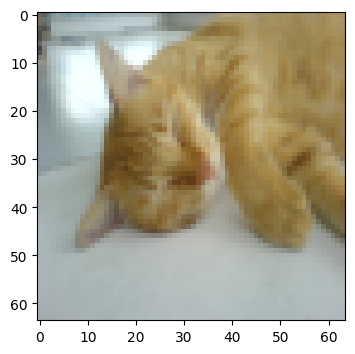

In [ ]:
# Ví dụ về hình ảnh
index = 121
plt.imshow(train_x_orig[index])
print('y=' + str(train_y[0,index]) + ".It's a "+ classes[train_y[0,index]].decode("utf-8")+ " picture.")

y=0.It's a non-catpicture.


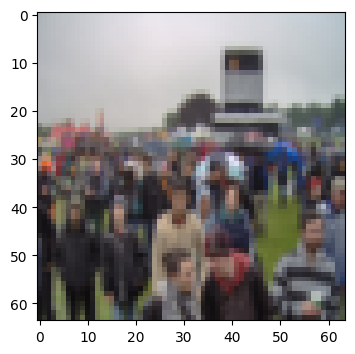

In [4]:
index = 100
plt.imshow(train_x_orig[index])
print('y=' + str(train_y[0,index]) + ".It's a "+ classes[train_y[0,index]].decode("utf-8")+"picture.")

In [5]:
# Explore your dataset 
m_train = train_x_orig.shape[0]
num_px = train_x_orig.shape[1]
m_test = test_x_orig.shape[0]

print ("Number of training examples: " + str(m_train))
print ("Number of testing examples: " + str(m_test))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_x_orig shape: " + str(train_x_orig.shape))
print ("train_y shape: " + str(train_y.shape))
print ("test_x_orig shape: " + str(test_x_orig.shape))
print ("test_y shape: " + str(test_y.shape))

Number of training examples: 209
Number of testing examples: 50
Each image is of size: (64, 64, 3)
train_x_orig shape: (209, 64, 64, 3)
train_y shape: (1, 209)
test_x_orig shape: (50, 64, 64, 3)
test_y shape: (1, 50)


As usual, you reshape and standardize the images before feeding them to the network. The code is given in the cell below.

<img src="images/imvectorkiank.png" style="width:450px;height:300px;">
<caption><center><font color='purple'><b>Figure 1</b>: Image to vector conversion.</font></center></caption>

In [6]:
# Định hình lại các mẫu huấn luyện và kiểm tra
train_x_flatten = train_x_orig.reshape(train_x_orig.shape[0],-1).T  # Giá trị "-1" khiến hàm reshape làm phẳng các chiều còn lại.
test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0],-1).T # test_x_orig.shape[0] là số lượng bức ảnh
train_x = train_x_flatten /255.
test_x = test_x_flatten / 255.
print ("train_x's shape: " + str(train_x.shape))
print ("test_x's shape: " + str(test_x.shape))

train_x's shape: (12288, 209)
test_x's shape: (12288, 50)


**Lưu ý**:
$12.288$ bằng $64 \times 64 \times 3$, đây là kích thước của một vectơ ảnh đã được thay đổi hình dạng.

<a name='3-1'></a>
### 3.1 - Mạng nơ-ron 2 lớp

Giờ đây khi đã quen thuộc với tập dữ liệu, đã đến lúc xây dựng một mạng nơ-ron sâu để phân biệt ảnh có mèo và ảnh không có mèo!

Bạn sẽ xây dựng hai mô hình khác nhau:

- Một mạng nơ-ron 2 lớp
- Một mạng nơ-ron sâu L lớp

Sau đó, bạn sẽ so sánh hiệu suất của các mô hình này và thử nghiệm với các giá trị $L$ khác nhau.

Hãy cùng xem xét hai kiến ​​trúc này:

<img src="images/2layerNN_kiank.png" style="width:650px;height:400px;">
<caption><center><font color='purple'><b>Hình 2</b>: Mạng nơ-ron 2 lớp. <br> Mô hình có thể được tóm tắt như sau: INPUT -> LINEAR -> RELU -> LINEAR -> SIGMOID -> OUTPUT.</font></center></caption>

<u><b>Chi tiết kiến ​​trúc của Hình 2</b></u>:
- Đầu vào là một hình ảnh có kích thước (64, 64, 3), được làm phẳng thành một vectơ có kích thước $(12288, 1)$.
- Vectơ tương ứng: $[x_0, x_1, ..., x_{12287}]^T$ sau đó được nhân với ma trận trọng số $W^{[1]}$ có kích thước $(n^{[1]}, 12288)$.
- Tiếp theo, cộng thêm hệ số bias (độ lệch) và áp dụng hàm ReLU để thu được vectơ: $[a_0^{[1]}, a_1^{[1]}, ..., a_{n^{[1]}-1}^{[1]}]^T$.
- Lặp lại quy trình tương tự.
- Nhân vectơ kết quả với $W^{[2]}$ và cộng thêm hệ số bias.
- Cuối cùng, áp dụng hàm sigmoid cho kết quả thu được. Nếu giá trị lớn hơn 0,5, phân loại đó là mèo. <a name='3-2'></a>
### 3.2 - Mạng nơ-ron sâu L lớp

Khá khó để biểu diễn một mạng nơ-ron sâu L lớp bằng cách biểu diễn đã nêu ở trên. Tuy nhiên, dưới đây là hình ảnh biểu diễn mạng đã được đơn giản hóa:

<img src="images/LlayerNN_kiank.png" style="width:650px;height:400px;">
<caption><center><font color='purple'><b>Hình 3</b>: Mạng nơ-ron L lớp. <br> Mô hình có thể được tóm tắt như sau: [LINEAR -> RELU] $\times$ (L-1) -> LINEAR -> SIGMOID</font></center></caption>

<u><b>Kiến trúc chi tiết của Hình 3</b></u>:
- Đầu vào là một hình ảnh có kích thước (64, 64, 3), được trải phẳng (flatten) thành một vectơ có kích thước (12288, 1).
- Vectơ tương ứng: $[x_0, x_1, ..., x_{12287}]^T$ sau đó được nhân với ma trận trọng số $W^{[1]}$ và cộng thêm hệ số chặn $b^{[1]}$. Kết quả thu được gọi là đơn vị tuyến tính (linear unit).
- Tiếp theo, áp dụng hàm ReLU lên đơn vị tuyến tính đó. Quá trình này có thể được lặp lại nhiều lần cho mỗi cặp $(W^{[l]}, b^{[l]})$ tùy thuộc vào kiến ​​trúc của mô hình.
- Cuối cùng, áp dụng hàm Sigmoid lên đơn vị tuyến tính sau cùng. Nếu giá trị lớn hơn 0,5, phân loại đó là mèo.

<a name='3-3'></a>
### 3.3 - Phương pháp luận tổng quát

Như thường lệ, bạn sẽ tuân theo quy trình xây dựng mô hình học sâu (Deep Learning):

1. Khởi tạo các tham số / Xác định các siêu tham số (hyperparameters)
2. Lặp lại trong `num_iterations` lần:
a. Lan truyền tiến (Forward propagation)
b. Tính hàm chi phí (cost function)
c. Lan truyền ngược (Backward propagation)
d. Cập nhật tham số (sử dụng các tham số hiện tại và đạo hàm/gradient từ bước lan truyền ngược)
3. Sử dụng các tham số đã được huấn luyện để dự đoán nhãn

Bây giờ, hãy bắt tay vào triển khai hai mô hình đó!

<a name='4'></a>
## 4 - Mạng nơ-ron hai lớp

<a name='ex-1'></a>
### Bài tập 1 - two_layer_model

Hãy sử dụng các hàm hỗ trợ mà bạn đã triển khai trong bài tập trước để xây dựng một mạng nơ-ron hai lớp với cấu trúc sau: *LINEAR -> RELU -> LINEAR -> SIGMOID*. Các hàm và tham số đầu vào của chúng bao gồm:
```python
def initialize_parameters(n_x, n_h, n_y):
...
return parameters
def linear_activation_forward(A_prev, W, b, activation):
...
return A, cache
def compute_cost(AL, Y):
...
return cost
def linear_activation_backward(dA, cache, activation):
...
return dA_prev, dW, db
def update_parameters(parameters, grads, learning_rate):
...
return parameters
```

In [7]:
### CONSTANTS DEFINING THE MODEL ####
n_x = 12288     # num_px * num_px * 3
n_h = 7
n_y = 1
layers_dims = (n_x, n_h, n_y)
learning_rate = 0.0075

In [ ]:
# GRADED FUNCTION: two_layer_model

def two_layer_model(X, Y, layers_dims, learning_rate = 0.0075, num_iterations = 3000, print_cost=False):
    """
    Implements a two-layer neural network: LINEAR->RELU->LINEAR->SIGMOID.
    
    Arguments:
    X -- input data, of shape (n_x, number of examples)
    Y -- true "label" vector (containing 1 if cat, 0 if non-cat), of shape (1, number of examples)
    layers_dims -- dimensions of the layers (n_x, n_h, n_y)
    num_iterations -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_cost -- If set to True, this will print the cost every 100 iterations 
    
    Returns:
    parameters -- a dictionary containing W1, W2, b1, and b2
    """
    np.random.seed(1)
    grads = {}
    costs =[]# để theo dõi chi phí
    m = X.shape[1]# number of examples
    (n_x,n_h,n_y) =layers_dims
    parameters = initialize_parameters(n_x , n_h , n_y)
    # Lấy W1, b1, W2 và b2 từ dictionary parameters.
    W1 = parameters['W1']
    b1 = parameters['b1']
    W2 = parameters['W2']
    b2 = parameters['b2']
    
    for i in range(0,num_iterations) :
        # Lan truyền tiến: LINEAR -> RELU -> LINEAR -> SIGMOID. Đầu vào: "X, W1, b1, W2, b2". Đầu ra: "A1, cache1, A2, cache2". 
        #(≈ 2 dòng mã)
        # A1, cache1 = ...
        # A2, cache2 = ...
        # MÃ CỦA BẠN BẮT ĐẦU TẠI ĐÂY
        A1 , cache1 = linear_activation_forward(X , W1 , b1 , activation ='relu')
        A2, cache2 = linear_activation_forward(A1, W2, b2, activation="sigmoid")
        
        # Compute cost
        cost = compute_cost(A2 ,Y)
        
        # Initializing backward propagation ( Tính gradient của A2 với Loss function)
        dA2 = -(np.divide(Y , A2) - np.divide(1-Y , 1-A2))

        # Backward propagation. Inputs: "dA2, cache2, cache1". Outputs: "dA1, dW2, db2; also dA0 (not used), dW1, db1".
        #(≈ 2 lines of code)
        # dA1, dW2, db2 = ...
        # dA0, dW1, db1 = ...
        # YOUR CODE STARTS HERE
        dA1, dW2, db2 = linear_activation_backward(dA2, cache2, activation="sigmoid")
        dA0, dW1, db1 = linear_activation_backward(dA1, cache1, activation="relu")
        
        
        # Gán grads['dW1'] bằng dW1, grads['db1'] bằng db1, grads['dW2'] bằng dW2, grads['db2'] bằng db2
        grads['dW1'] = dW1
        grads['db1'] = db1
        grads['dW2'] = dW2
        grads['db2'] = db2
        
        #Cập nhật tham số
        paremeters = update_parameters(parameters , grads , learning_rate) 
        
        
        # Lấy W1, b1, W2, b2 từ các tham số
        W1 = parameters['W1']   
        b1 = parameters["b1"]
        W2 = parameters["W2"]
        b2 = parameters["b2"]
        if print_cost and i % 100 == 0 or i == num_iterations - 1:
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        #np.squeeze() trong NumPy được dùng để loại bỏ tất cả các chiều (dimensions) có kích thước bằng 1 ra khỏi một mảng
        if i % 100 == 0 or i == num_iterations:
            costs.append(cost)

    return parameters, costs
def plot_costs(costs, learning_rate=0.0075):
    plt.plot(np.squeeze(costs))
    plt.ylabel('cost')
    plt.xlabel('iterations (per hundreds)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()

In [9]:
parameters, costs = two_layer_model(train_x, train_y, layers_dims = (n_x, n_h, n_y), num_iterations = 2, print_cost=False)

print("Cost after first iteration: " + str(costs[0]))

two_layer_model_test(two_layer_model)

Cost after iteration 1: 0.6926114346158595
Cost after first iteration: 0.693049735659989
Cost after iteration 1: 0.6915746967050506
Cost after iteration 1: 0.6915746967050506
Cost after iteration 1: 0.6915746967050506
Cost after iteration 2: 0.6524135179683452
 All tests passed.


<a name='4-1'></a>
### 4.1 - Huấn luyện mô hình

Nếu mã của bạn đã chạy thành công ở ô trước, hãy chạy ô dưới đây để huấn luyện các tham số.

- Giá trị hàm chi phí (cost) sẽ giảm dần qua mỗi lần lặp.

- Quá trình chạy 2500 lần lặp có thể mất tới 5 phút.

Cost after iteration 0: 0.693049735659989
Cost after iteration 100: 0.6464320953428849
Cost after iteration 200: 0.6325140647912678
Cost after iteration 300: 0.6015024920354665
Cost after iteration 400: 0.5601966311605747
Cost after iteration 500: 0.5158304772764729
Cost after iteration 600: 0.4754901313943325
Cost after iteration 700: 0.43391631512257495
Cost after iteration 800: 0.400797753620389
Cost after iteration 900: 0.35807050113237987
Cost after iteration 1000: 0.3394281538366412
Cost after iteration 1100: 0.30527536361962654
Cost after iteration 1200: 0.27491377282130197
Cost after iteration 1300: 0.24681768210614816
Cost after iteration 1400: 0.1985073503746609
Cost after iteration 1500: 0.17448318112556646
Cost after iteration 1600: 0.17080762978096473
Cost after iteration 1700: 0.11306524562164719
Cost after iteration 1800: 0.09629426845937154
Cost after iteration 1900: 0.08342617959726861
Cost after iteration 2000: 0.0743907870431908
Cost after iteration 2100: 0.066307481

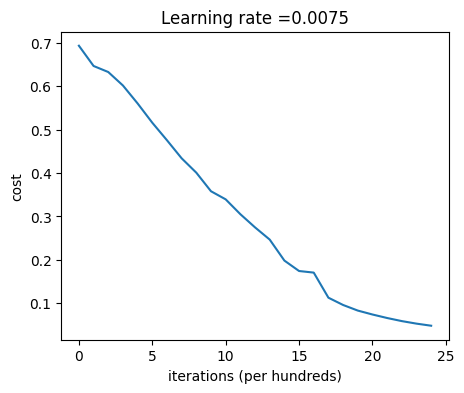

In [10]:
parameters, costs = two_layer_model(train_x, train_y, layers_dims = (n_x, n_h, n_y), num_iterations = 2500, print_cost=True)
plot_costs(costs, learning_rate)

In [11]:
predictions_train = predict(train_x , train_y , parameters)


Accuracy: 0.9999999999999998


In [12]:
predictions_test = predict(test_x, test_y, parameters)

Accuracy: 0.72


### Chúc mừng bạn! Có vẻ như mạng thần kinh 2 lớp của bạn đạt hiệu suất tốt hơn (72%) so với mô hình hồi quy logistic (70%, bài tập tuần 2). Hãy cùng xem liệu bạn có thể đạt kết quả tốt hơn nữa với mô hình $L$ lớp hay không.

**Lưu ý**: Bạn có thể nhận thấy rằng việc chạy mô hình với số vòng lặp ít hơn (ví dụ: 1500 vòng) lại mang lại độ chính xác cao hơn trên tập kiểm thử. Kỹ thuật này được gọi là "dừng sớm" (early stopping) và bạn sẽ được tìm hiểu kỹ hơn về nó trong khóa học tiếp theo. Dừng sớm là một phương pháp giúp ngăn ngừa hiện tượng quá khớp (overfitting).

<a name='5'></a>
## 5 - Mạng nơ-ron $L$ lớp

<a name='ex-2'></a>
### Bài tập 2 - L_layer_model

Hãy sử dụng các hàm hỗ trợ mà bạn đã triển khai trước đó để xây dựng một mạng nơ-ron $L$ lớp với cấu trúc sau: *[LINEAR -> RELU]$\times$(L-1) -> LINEAR -> SIGMOID*. Các hàm và tham số đầu vào của chúng bao gồm:
```python
def initialize_parameters_deep(layers_dims):
...
return parameters
def L_model_forward(X, parameters):
...
return AL, caches
def compute_cost(AL, Y):
...
return cost
def L_model_backward(AL, Y, caches):
...
return grads
def update_parameters(parameters, grads, learning_rate):
...
return parameters
```

In [13]:
### CONSTANTS ###
layers_dims = [12288, 20, 7, 5, 1] #  4-layer model
# n_x = n0 = 1228(Input Layer): Kích thước vector đầu vào của mỗi mẫu dữ liệu ,  từ một bức ảnh màu kích thước 64 x 64 với 3 kênh màu RGB
# n1 = 20 (Hidden Layer 1): Tầng ẩn thứ nhất gồm 20 nơ-ron.
# n2 = 7 (Hidden Layer 2): Tầng ẩn thứ hai gồm 7 nơ-ron.
# n3 = 5 (Hidden Layer 3): Tầng ẩn thứ ba gồm 5 nơ-ron.
# n4 = 1 (Output Layer): Tầng đầu ra gồm 1 nơ-ron (dùng hàm kích hoạt Sigmoid để dự đoán xác suất nhị phân, ví dụ: 1 là mèo, 0 là không phải mèo).

In [14]:
# GRADED FUNCTION: L_layer_model

def L_layer_model(X, Y, layers_dims, learning_rate = 0.0075, num_iterations = 3000, print_cost=False):
    """
    Implements a L-layer neural network: [LINEAR->RELU]*(L-1)->LINEAR->SIGMOID.
    
    Arguments:
    X -- data, numpy array of shape (num_px * num_px * 3, number of examples)
    Y -- true "label" vector (containing 0 if cat, 1 if non-cat), of shape (1, number of examples)
    layers_dims -- list containing the input size and each layer size, of length (number of layers + 1).
    learning_rate -- learning rate of the gradient descent update rule
    num_iterations -- number of iterations of the optimization loop
    print_cost -- if True, it prints the cost every 100 steps
    
    Returns:
    parameters -- parameters learnt by the model. They can then be used to predict.
    """

    np.random.seed(1)
    costs = []                         # keep track of cost
    
    # Parameters initialization.
    #(≈ 1 line of code)
    # parameters = ...
    # YOUR CODE STARTS HERE
    parameters = initialize_parameters_deep(layers_dims)
    # YOUR CODE ENDS HERE
    
    # Loop (gradient descent)
    for i in range(0, num_iterations):

        # Forward propagation: [LINEAR -> RELU]*(L-1) -> LINEAR -> SIGMOID.
        #(≈ 1 line of code)
        # AL, caches = ...
        # YOUR CODE STARTS HERE
        AL, caches = L_model_forward(X, parameters)
        # YOUR CODE ENDS HERE
        
        # Compute cost.
        #(≈ 1 line of code)
        # cost = ...
        # YOUR CODE STARTS HERE
        cost = compute_cost(AL, Y)
        # YOUR CODE ENDS HERE
    
        # Backward propagation.
        #(≈ 1 line of code)
        # grads = ...    
        # YOUR CODE STARTS HERE
        grads = L_model_backward(AL, Y, caches)
        # YOUR CODE ENDS HERE
 
        # Update parameters.
        #(≈ 1 line of code)
        # parameters = ...
        # YOUR CODE STARTS HERE
        parameters = update_parameters(parameters, grads, learning_rate)
        # YOUR CODE ENDS HERE
        
        # Print the cost every 100 iterations
        if print_cost and i % 100 == 0 or i == num_iterations - 1 :# cập nhật vòng cuối khi không chia hết cho 100
            print('Cost after interation {} :{}'.format(i , np.squeeze(cost)))
        if i % 100 == 0 or i == num_iterations :
            costs.append(cost)
    return parameters, costs

In [15]:
parameters, costs = L_layer_model(train_x, train_y, layers_dims, num_iterations = 1, print_cost = False)

print("Cost after first iteration: " + str(costs[0]))

L_layer_model_test(L_layer_model)

Cost after interation 0 :0.7717493284237686
Cost after first iteration: 0.7717493284237686
Cost after interation 1 :0.7070709008912569
Cost after interation 1 :0.7070709008912569
Cost after interation 1 :0.7070709008912569
Cost after interation 2 :0.7063462654190897
 All tests passed.


<a name='5-1'></a>
### 5.1 - Train the model 

If your code passed the previous cell, run the cell below to train your model as a 4-layer neural network. 

- The cost should decrease on every iteration. 

- It may take up to 5 minutes to run 2500 iterations. 

In [16]:
parameters, costs = L_layer_model(train_x, train_y, layers_dims, num_iterations = 2500, print_cost = True)

Cost after interation 0 :0.7717493284237686
Cost after interation 100 :0.6720534400822914
Cost after interation 200 :0.6482632048575212
Cost after interation 300 :0.6115068816101354
Cost after interation 400 :0.5670473268366111
Cost after interation 500 :0.5401376634547801
Cost after interation 600 :0.5279299569455267
Cost after interation 700 :0.4654773771766851
Cost after interation 800 :0.36912585249592794
Cost after interation 900 :0.39174697434805344
Cost after interation 1000 :0.3151869888600617
Cost after interation 1100 :0.2726998441789385
Cost after interation 1200 :0.23741853400268134
Cost after interation 1300 :0.19960120532208644
Cost after interation 1400 :0.18926300388463305
Cost after interation 1500 :0.16118854665827748
Cost after interation 1600 :0.14821389662363316
Cost after interation 1700 :0.13777487812972944
Cost after interation 1800 :0.12974017549190123
Cost after interation 1900 :0.12122535068005211
Cost after interation 2000 :0.11382060668633713
Cost after int